## Linear regression with single variable

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

df= pd.read_csv("C://Users//USER//Downloads//canada_per_capita_income.csv")
regression= linear_model.LinearRegression()
regression.fit(df[['year']], df['per capita income (US$)'])
regression.predict(pd.DataFrame({'year': [2020]}))
plt.scatter(df['year'], df['per capita income (US$)'])
plt.plot(df['year'], regression.predict(df[['year']]), color='red')
plt.plot([2020], regression.predict(pd.DataFrame({'year': [2020]})), color='black', marker='o')
plt.show()

## Linear regression with multiple variables

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
import math

df= pd.read_csv("C://Users//USER//Downloads//homeprices.csv")
df['bedrooms']= df['bedrooms'].fillna(math.floor(df['bedrooms'].median()))
regression= linear_model.LinearRegression()
regression.fit(df[['area', 'bedrooms', 'age']], df['price'])
regression.predict(pd.DataFrame({'area': [3000], 'bedrooms':[3], 'age':[40]}))
regression.predict(pd.DataFrame({'area': [2500], 'bedrooms':[4], 'age':[5]}))

array([578876.03748933])

## Linear regression with multiple variables and saving model into a file

In [24]:
!pip install joblib

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
import math
from word2number import w2n
import joblib


df= pd.read_csv("C://Users//USER//Downloads//hiring.csv")
df['experience']=df['experience'].fillna('zero')
df['experience']=df['experience'].apply(w2n.word_to_num)
df['test_score(out of 10)']=df['test_score(out of 10)'].fillna(math.floor(df['test_score(out of 10)'].mean()))

regression= linear_model.LinearRegression()
regression.fit(df[['experience', 'test_score(out of 10)', 'interview_score(out of 10)']], df['salary($)'])
joblib.dump(regression, 'C://Users//USER//Downloads//trained_model_for_linear_regression')

model= joblib.load('C://Users//USER//Downloads//trained_model_for_linear_regression')
model.predict(pd.DataFrame({'experience': [2], 'test_score(out of 10)':[9], 'interview_score(out of 10)':[6]}))
#model.predict(pd.DataFrame({'experience': [12], 'test_score(out of 10)':[10], 'interview_score(out of 10)':[10]}))

array([53713.86677124])

## Linear regression with Dummy Variables

In [46]:
import pandas as pd
import numpy as np
from sklearn import linear_model

df= pd.read_csv("C://Users//USER//Downloads//carprices.csv")
new_columns= pd.get_dummies(df['Car Model'])
df= pd.concat([df, new_columns], axis='columns')
df= df.drop(columns= ['Car Model', 'Mercedez Benz C class'])

regression= linear_model.LinearRegression()
regression.fit(df[['Mileage', 'Age(yrs)', 'Audi A5', 'BMW X5']], df['Sell Price($)'])
regression.score(df[['Mileage', 'Age(yrs)', 'Audi A5', 'BMW X5']], df['Sell Price($)'])
regression.predict(pd.DataFrame({'Mileage': [86000], 'Age(yrs)': [7], 'Audi A5': [0], 'BMW X5': [1]}))

array([11080.74313219])

## Split: Training and Testing data

In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import linear_model

df= pd.read_csv("C://Users//USER//Downloads//carprices.csv")
X= df[['Mileage', 'Age(yrs)']]
y= df['Sell Price($)']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2)
regression= linear_model.LinearRegression()
regression.fit(X_train, y_train)
regression.score(X_test, y_test)
regression.predict(X_test)

array([25964.83787884, 27670.69449374, 30081.12882388, 16367.57069683])

## Logistic regression for Binary Classification

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

df= pd.read_csv('C://Users//USER//Downloads//insurance_data.csv')
X= df[['age']]
y= df['bought_insurance']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.1, random_state= 44)
model= LogisticRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)
#model.predict(X_test)

Exploratory analysis

In [169]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

df= pd.read_csv('C://Users//USER//Downloads//HR_comma_sep.csv')
df= df.drop(columns=['Department', 'Work_accident', 'number_project', 'last_evaluation'])
df['salary']= df['salary'].map({'low': -1, 'medium': 0, 'high': 1})
#df.groupby('left').median()
#df.groupby('left').mean()

In [171]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


df= pd.read_csv('C://Users//USER//Downloads//HR_comma_sep.csv')
df['salary']= df['salary'].map({'low': -1, 'medium': 0, 'high': 1})
X= df[['satisfaction_level', 'average_montly_hours', 'promotion_last_5years', 'salary']]
y= df['left']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.1)
model= LogisticRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)
#model.predict(X_test)

0.7846666666666666

## Logistic regression for Multiclass Classification

Text(0.5, 47.7222222222222, 'Predicted')

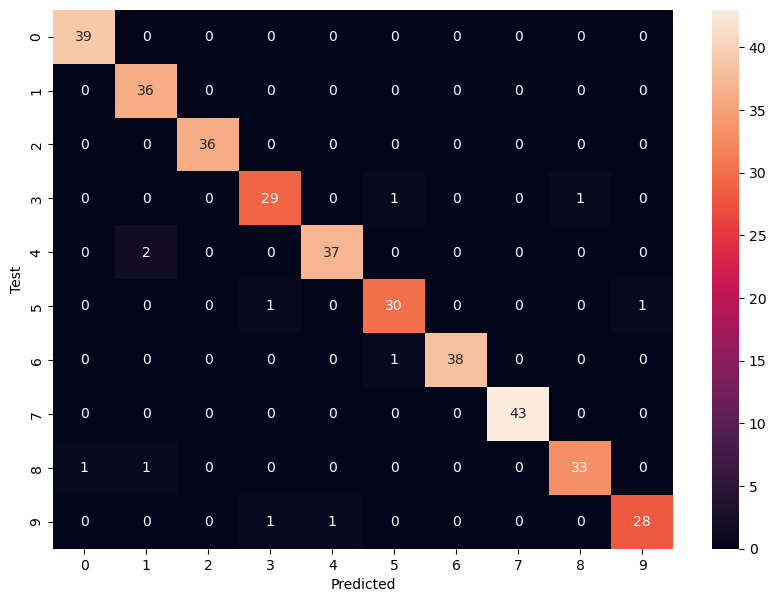

In [47]:
from matplotlib import pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import seaborn as sn

digits= load_digits()
#dir(digits)
#digits.data[0]
#plt.gray()
#plt.matshow(digits.images[0])
X_train, X_test, y_train, y_test= train_test_split(digits['data'], digits['target'], test_size= 0.2)
model= LogisticRegression(max_iter=260)
model.fit(X_train, y_train)
model.score(X_test, y_test)
# plt.matshow(digits.images[67])
# digits['target'][67]
# model.predict([digits['data'][67]])
y_predicted= model.predict(X_test)
cm= confusion_matrix(y_test, y_predicted)
cm
plt.figure(figsize=(10,7))
sn.heatmap(cm, annot=True)
plt.ylabel('Test')
plt.xlabel('Predicted')

Text(0.5, 47.7222222222222, 'Predicted')

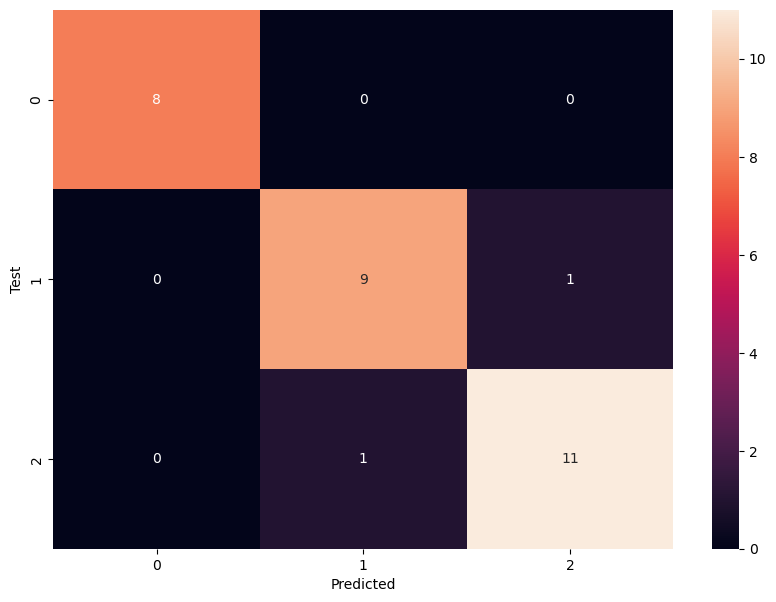

In [91]:
from matplotlib import pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import seaborn as sn


iris= load_iris()
X_train, X_test, y_train, y_test= train_test_split(iris['data'], iris['target'], test_size= 0.2)
model= LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
model.score(X_test, y_test)

#iris['target'][97]
#model.predict([iris['data'][97]])
y_predicted= model.predict(X_test)
cm= confusion_matrix(y_test, y_predicted)
cm
plt.figure(figsize=(10,7))
sn.heatmap(cm, annot=True)
plt.ylabel('Test')
plt.xlabel('Predicted')

## Decision tree

In [42]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import tree

df= pd.read_csv("C://Users//USER//Downloads//titanic.csv")
df['Sex_n']= LabelEncoder().fit_transform(df['Sex'])
df= df.drop(columns=['PassengerId', 'Name', 'SibSp', 'Parch', 'Ticket', 'Cabin', 'Embarked', 'Sex'])
X= df[['Pclass', 'Sex_n', 'Age', 'Fare']]
y= df['Survived']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.1)
model= tree.DecisionTreeClassifier()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.8111111111111111

## Support Vector Machine

In [51]:
import pandas as pd
from sklearn.datasets import load_iris
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC


iris= load_iris()
df= pd.DataFrame(iris.data, columns= iris.feature_names)
df['target']= iris.target
df['flower_name']= df['target'].apply(lambda x: iris.target_names[x])
#df0= df[df['target']==0]
#df1= df[df['target']==1]
#df2= df[df['target']==2]
X= df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]
y= df['target']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2)
model= SVC()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.9666666666666667

In [52]:
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

digits= load_digits()
X= digits['data']
y= digits['target']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2)
model= SVC()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.9944444444444445

Text(0.5, 47.7222222222222, 'Predicted')

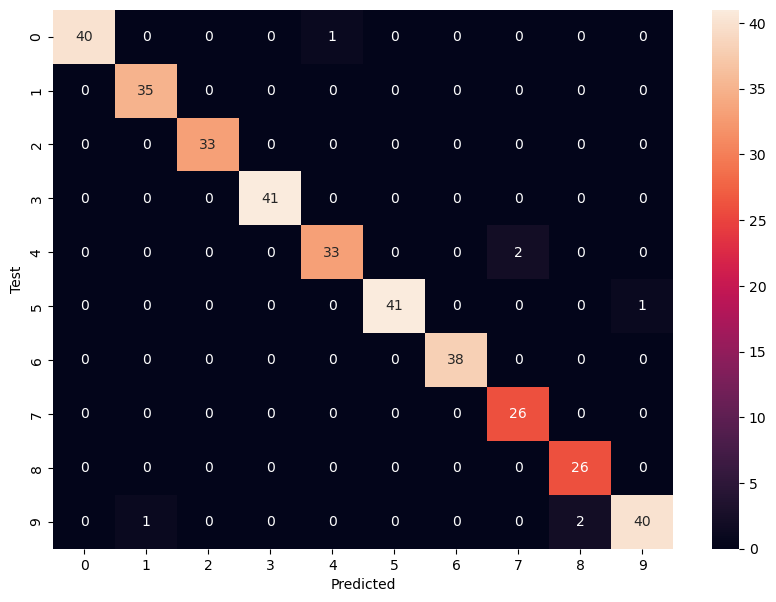

In [58]:
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sn

digits= load_digits()
X= digits['data']
y= digits['target']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2)
model= RandomForestClassifier(n_estimators=200)
model.fit(X_train, y_train)
model.score(X_test, y_test)
y_predicted= model.predict(X_test)
cm= confusion_matrix(y_test, y_predicted)
cm
plt.figure(figsize=(10,7))
sn.heatmap(cm, annot=True)
plt.ylabel('Test')
plt.xlabel('Predicted')

## Random Forest Classifier

In [60]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sn

iris= load_iris()
X= iris['data']
y= iris['target']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2)
model= RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)
model.score(X_test, y_test)
#y_predicted= model.predict(X_test)
#cm= confusion_matrix(y_test, y_predicted)
#cm
#plt.figure(figsize=(10,7))
#sn.heatmap(cm, annot=True)
#plt.ylabel('Test')
#plt.xlabel('Predicted')

1.0

## K-fold Cross Validation

In [77]:
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

iris= load_iris()
cross_val_score(LinearRegression(), iris['data'], iris['target'])
cross_val_score(LogisticRegression(max_iter=150), iris['data'], iris['target'])
cross_val_score(DecisionTreeClassifier(), iris['data'], iris['target'])
cross_val_score(SVC(), iris['data'], iris['target'])
cross_val_score(RandomForestClassifier(n_estimators=250), iris['data'], iris['target'])

array([0.96666667, 0.96666667, 0.93333333, 0.93333333, 1.        ])

## K-Means Clustering Algorithm

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


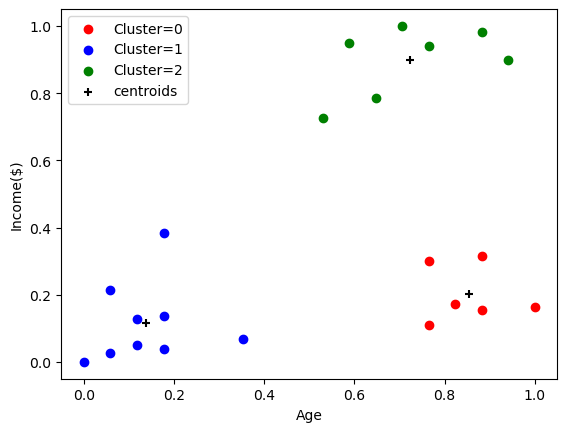

In [96]:
from sklearn.cluster import KMeans
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler

df= pd.read_csv("C://Users//USER//Downloads//income.csv")
scaler= MinMaxScaler()
scaler.fit(df[['Income($)']])
df['Income($)']= scaler.transform(df[['Income($)']])
scaler.fit(df[['Age']])
df['Age']= scaler.transform(df[['Age']])
#plt.scatter(df['Age'], df['Income($)'], marker='o', color='blue')
#k_rng= range(1,10)
#sse= []
#for k in k_rng:
#    km= KMeans(n_clusters=k)
#    km.fit(df[['Age', 'Income($)']])
#    sse.append(km.inertia_)

#plt.xlabel('k')
#plt.ylabel('sse')
#plt.plot(k_rng, sse)
km= KMeans(n_clusters=3)
y_predicted= km.fit_predict(df[['Age', 'Income($)']])
df['cluster']= y_predicted
df0= df[df['cluster']==0]
df1= df[df['cluster']==1]
df2= df[df['cluster']==2]
plt.scatter(df0['Age'], df0['Income($)'], color='red', label='Cluster=0')
plt.scatter(df1['Age'], df1['Income($)'], color='blue', label='Cluster=1')
plt.scatter(df2['Age'], df2['Income($)'], color='green', label='Cluster=2')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], color='black', marker='+', label='centroids')
plt.xlabel('Age')
plt.ylabel('Income($)')
plt.legend()

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


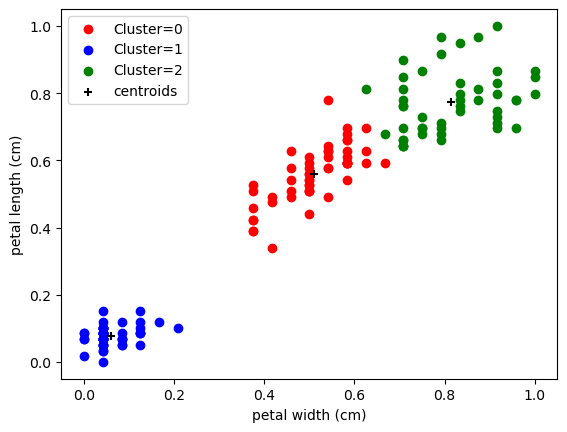

In [121]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler

iris= load_iris()
df= pd.DataFrame(iris.data, columns= iris.feature_names)
df= df.drop(columns=['sepal length (cm)', 'sepal width (cm)'])
scaler= MinMaxScaler()
scaler.fit(df[['petal length (cm)']])
df['petal length (cm)']= scaler.transform(df[['petal length (cm)']])
scaler.fit(df[['petal width (cm)']])
df['petal width (cm)']= scaler.transform(df[['petal width (cm)']])
#plt.scatter(df['petal width (cm)'], df['petal length (cm)'], marker='o', color='blue')


#k_rng= range(1,10)
#sse= []
#for k in k_rng:
#    km= KMeans(n_clusters=k)
#    km.fit(df[['petal width (cm)', 'petal length (cm)']])
#    sse.append(km.inertia_)

#plt.xlabel('k')
#plt.ylabel('sse')
#plt.plot(k_rng, sse)


km= KMeans(n_clusters=3)
y_predicted= km.fit_predict(df[['petal width (cm)', 'petal length (cm)']])
df['cluster']= y_predicted
df0= df[df['cluster']==0]
df1= df[df['cluster']==1]
df2= df[df['cluster']==2]
plt.scatter(df0['petal width (cm)'], df0['petal length (cm)'], color='red', label='Cluster=0')
plt.scatter(df1['petal width (cm)'], df1['petal length (cm)'], color='blue', label='Cluster=1')
plt.scatter(df2['petal width (cm)'], df2['petal length (cm)'], color='green', label='Cluster=2')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], color='black', marker='+', label='centroids')
plt.xlabel('petal width (cm)')
plt.ylabel('petal length (cm)')
plt.legend()

## Naive Bayes

In [132]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

df= pd.read_csv("C://Users//USER//Downloads//titanic.csv")
new_columns= pd.get_dummies(df['Sex'])
df= pd.concat([df, new_columns], axis='columns')
df= df.drop(columns=['PassengerId', 'Name', 'SibSp', 'Parch', 'Ticket', 'Cabin', 'Embarked', 'Sex', 'female'])
df['Age']= df['Age'].fillna(df['Age'].mean())
X= df[['Pclass', 'male', 'Age', 'Fare']]
y= df['Survived']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2)
model= GaussianNB()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.7821229050279329

In [147]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline

df= pd.read_csv("C://Users//USER//Downloads//spam.csv")
#df.groupby('Category').describe()
df['Category_n']= LabelEncoder().fit_transform(df['Category'])
df= df.drop(columns=['Category'])
X= df['Message']
y= df['Category_n']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2)
model= Pipeline([('vectorizer', CountVectorizer()), ('nb', MultinomialNB())])
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.9811659192825112

In [185]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

wine=load_wine()
A= pd.DataFrame(wine['data'], columns=wine['feature_names'])
B= pd.DataFrame(wine['target'], columns=['target'])
df= pd.concat([A, B], axis='columns')
df.columns[df.isna().any()]
df
X= df.drop(columns=['target'])
X
y= df['target']
y
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2)
model= GaussianNB()
#model= MultinomialNB()
model.fit(X_train, y_train)
model.score(X_test, y_test)

1.0

## Hyper-parameter Tuning: Choosing best parameters

In [205]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV   #GridSearchCV checks every possible combination of parameters
from sklearn.model_selection import RandomizedSearchCV #RandomizedSearchCV is a time-efficient version of GridSearchCV, as rs takes random samples rather than taking all possible combinations
from sklearn.svm import SVC
import pandas as pd

iris= load_iris()
df= pd.DataFrame(iris['data'], columns=iris['feature_names'])
df['target']= iris['target']
df['flower']= df['target'].apply(lambda x: iris['target_names'][x])
X= df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]
y=df['target']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2)
#clf= GridSearchCV(SVC(gamma= 'auto'), {'kernel':['rbf','linear'], 'C':[1,10,20]}, cv= 5, return_train_score= False)
#clf.fit(X,y)
#pd.DataFrame(clf.cv_results_)[['param_C', 'param_kernel', 'mean_test_score']]
#clf.best_params_
# or, the following way:
#clf= RandomizedSearchCV(SVC(gamma= 'auto'), {'kernel':['rbf','linear'], 'C':[1,10,20]}, cv= 5, return_train_score= False, n_iter=2)
#clf.fit(X,y)
#pd.DataFrame(clf.cv_results_)[['param_C', 'param_kernel', 'mean_test_score']]
#clf.best_params_
model= SVC(kernel='rbf', C=1.0, gamma='auto')
model.fit(X_train, y_train)
model.score(X_test, y_test)

1.0

## Hyper-parameter Tuning: Choosing best model

In [214]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV  
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd

iris= load_iris()
df= pd.DataFrame(iris['data'], columns=iris['feature_names'])
df['target']= iris['target']
df['flower']= df['target'].apply(lambda x: iris['target_names'][x])
X= df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]
y=df['target']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2)

model_params={
    'svm':{
        'model': SVC(gamma='auto'),
        'params':{
            'C':[1,5,10],
            'kernel': ['rbf', 'linear']
        }
    },
    'random_forest':{
        'model': RandomForestClassifier(),
        'params':{
            'n_estimators':[1,5,10]
        }
    },
    'logistic_regression':{
        'model': LogisticRegression(max_iter=200),
        'params':{
            'C':[1,5,10]
        }
    }
}
scores=[]
for model_name, mp in model_params.items():
    clf= GridSearchCV(mp['model'], mp['params'], cv=5, return_train_score=False)
    clf.fit(X, y)
    scores.append({
        'model': model_name,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
pd.DataFrame(scores)    

,model,best_score,best_params
0,svm,0.980000,"{'C': 1, 'kernel': 'rbf'}"
1,random_forest,0.960000,{'n_estimators': 10}
2,logistic_regression,0.973333,{'C': 1}


In [217]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV  
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
import pandas as pd


digits= load_digits()
X= digits['data']
y=digits['target']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2)

model_params={
    'svm':{
        'model': SVC(gamma='auto'),
        'params':{
            'C':[1,5,10],
            'kernel': ['rbf', 'linear']
        }
    },
    'random_forest':{
        'model': RandomForestClassifier(),
        'params':{
            'n_estimators':[1,5,10]
        }
    },
    'logistic_regression':{
        'model': LogisticRegression(max_iter=200),
        'params':{
            'C':[1,5,10]
        }
    },
    'GaussianNB':{
        'model': GaussianNB(),
        'params':{
            'var_smoothing':[1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
        }
    },
    'MultinomialNB':{
        'model': MultinomialNB(),
        'params':{
            'alpha': [0.1, 0.5, 1.0, 5.0, 10.0]
        }
    },
    'DecisionTreeClassifier':{
        'model': DecisionTreeClassifier(),
        'params':{
            'max_depth': [None, 5, 10, 20],
            'min_samples_split': [2,5,10],
            'min_samples_leaf': [1,2,5]
        }
    }
}

scores=[]
for model_name, mp in model_params.items():
    clf= GridSearchCV(mp['model'], mp['params'], cv=5, return_train_score=False)
    clf.fit(X, y)
    scores.append({
        'model': model_name,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
pd.DataFrame(scores) 

,model,best_score,best_params
0,svm,0.947697,"{'C': 1, 'kernel': 'linear'}"
1,random_forest,0.907646,{'n_estimators': 10}
2,logistic_regression,0.914878,{'C': 1}
3,GaussianNB,0.847541,{'var_smoothing': 1e-05}
4,MultinomialNB,0.874246,{'alpha': 10.0}
5,DecisionTreeClassifier,0.798024,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."


## L1(Lasso) and L2(Ridge) Regularization

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model
from sklearn.model_selection import train_test_split


df= pd.read_csv("C://Users//USER//Downloads//Melbourne_housing_FULL.csv")
df= df.drop(columns=['Method', 'SellerG', 'Date', 'Lattitude', 'Longtitude', 'Address', 'CouncilArea', 'Regionname', 'Suburb'])
df['Bedroom2']= df['Bedroom2'].fillna(df['Bedroom2'].mean())
df['Bathroom']= df['Bathroom'].fillna(df['Bathroom'].mean())
df['Car']= df['Car'].fillna(df['Car'].mean())
df['Landsize']= df['Landsize'].fillna(df['Landsize'].mean())
df['BuildingArea']= df['BuildingArea'].fillna(df['BuildingArea'].mean())
df['YearBuilt']= df['YearBuilt'].fillna(df['YearBuilt'].mean())
df= df.dropna()
df= pd.get_dummies(df, drop_first=True)
df.dtypes
X= df.drop(columns=['Price'])
y=df['Price']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.3)
model= linear_model.LinearRegression()
#model= linear_model.Lasso(alpha=1, max_iter=100, tol=0.1)
#model= linear_model.Ridge(alpha=1, max_iter=200, tol=1)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.47139631405220017

## K-Nearest Neighbour(KNN) Classifier

Text(0.5, 47.7222222222222, 'Predicted')

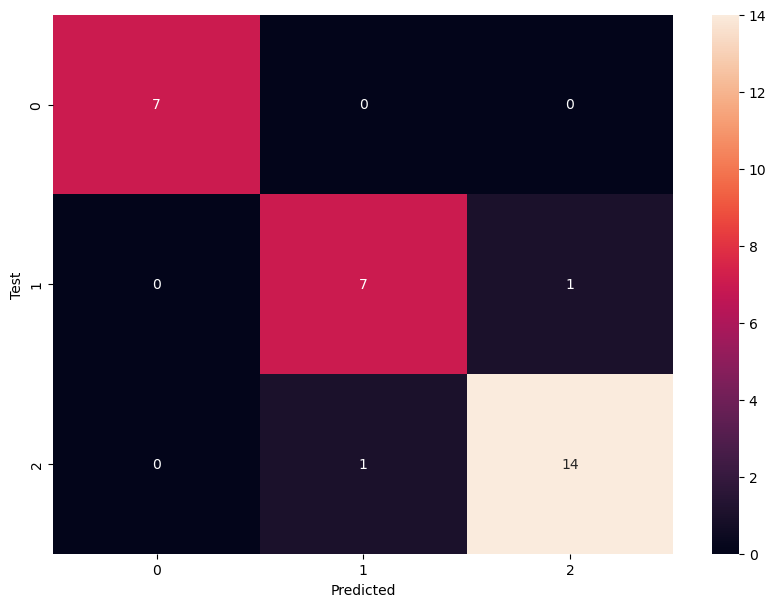

In [35]:
import pandas as pd
from sklearn.datasets import load_iris
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

iris= load_iris()
df= pd.DataFrame(iris.data, columns= iris.feature_names)
df['target']= iris.target
df['flower_name']= df['target'].apply(lambda x: iris.target_names[x])
#df0= df[df['target']==0]
#df1= df[df['target']==1]
#df2= df[df['target']==2]
X= df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]
y= df['target']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2)
model= KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)
y_predicted= model.predict(X_test)
#model.score(X_test, y_test)
#print(classification_report(y_test, y_predicted))
cm= confusion_matrix(y_test, y_predicted)
cm
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True)
plt.ylabel('Test')
plt.xlabel('Predicted')

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       0.98      1.00      0.99        47
           2       1.00      1.00      1.00        32
           3       0.98      1.00      0.99        41
           4       0.97      1.00      0.98        29
           5       1.00      0.97      0.99        39
           6       1.00      1.00      1.00        34
           7       1.00      0.97      0.99        35
           8       0.97      0.97      0.97        37
           9       0.95      0.92      0.93        38

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



Text(0.5, 47.7222222222222, 'Predicted')

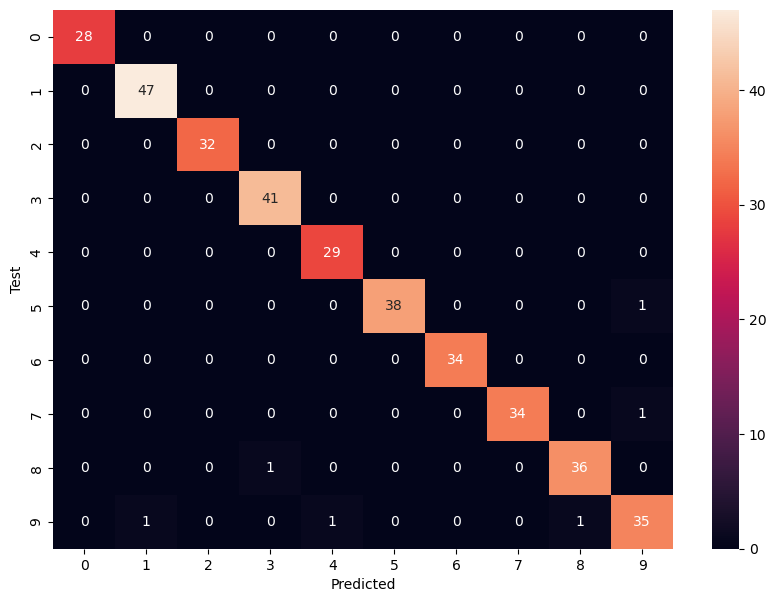

In [58]:
import pandas as pd
from sklearn.datasets import load_digits
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV  


digits= load_digits()
X= digits['data']
y= digits['target']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2)

#scores=[]
#for i in range(1,100):
#    model= KNeighborsClassifier(n_neighbors=i)
#    model.fit(X_train, y_train)
#    scores.append({'score': model.score(X_test, y_test), 'param': i})
#df= pd.DataFrame(scores)
#df[df['score']== df['score'].max()]
# Or,
#clf= GridSearchCV(KNeighborsClassifier(), {'n_neighbors':[1,2,3,4,5,6,7,8,9,10]}, cv=5, return_train_score=False)
#clf.fit(X_train, y_train)
#clf.best_params_

model= KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)
y_predicted= model.predict(X_test)
model.score(X_test, y_test)
print(classification_report(y_test, y_predicted))
cm= confusion_matrix(y_test, y_predicted)
cm
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True)
plt.ylabel('Test')
plt.xlabel('Predicted')

## Principal Component Analysis(PCA)

In [72]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

digits= load_digits()
X= digits['data']
y= digits['target']
X= StandardScaler().fit_transform(X)
#X.shape
#X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state=44)
X_pca= PCA(0.95).fit_transform(X)
#X_pca.shape
X_train, X_test, y_train, y_test= train_test_split(X_pca, y, test_size= 0.2, random_state=44)
model= LogisticRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.975

Bias means the variation in train-error; Variance means the variation in test-error
High bias means underfitting; while High variance means overfitting

## Bagging

In [91]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import BaggingClassifier

df= pd.read_csv("C://Users//USER//Downloads//diabetes.csv")
X= df.drop(columns=['Outcome'])
y= df['Outcome']
X= StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test= train_test_split(X, y, stratify=y, random_state=44)
#scores= cross_val_score(DecisionTreeClassifier(), X, y, cv=5)
#scores
bag_model= BaggingClassifier(
    estimator= DecisionTreeClassifier(),
    n_estimators= 100,
    max_samples= 0.8,
    oob_score= True,
    random_state= 44
)
bag_model.fit(X_train, y_train)
bag_model.oob_score_
scores= cross_val_score(bag_model, X, y, cv=5)
scores.mean()

np.float64(0.7617604617604616)

In [121]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import BaggingClassifier

df= pd.read_csv("C://Users//USER//Downloads//heart.csv")
df= pd.concat([df.drop(columns=['Sex']), pd.get_dummies(df['Sex'], drop_first=True, prefix='Sex')], axis='columns')
df= pd.concat([df.drop(columns=['RestingECG']), pd.get_dummies(df['RestingECG'], drop_first=True, prefix='RestingECG')], axis='columns')
df= pd.concat([df.drop(columns=['ExerciseAngina']), pd.get_dummies(df['ExerciseAngina'], drop_first=True, prefix='ExerciseAngina')], axis='columns')
df= pd.concat([df.drop(columns=['ST_Slope']), pd.get_dummies(df['ST_Slope'], drop_first=True, prefix='ST_Slope')], axis='columns')
df= pd.concat([df.drop(columns=['ChestPainType']), pd.get_dummies(df['ChestPainType'], drop_first=True, prefix='ChestPainType')], axis='columns')
df

X= df.drop(columns=['HeartDisease'])
y= df['HeartDisease']
X= StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test= train_test_split(X, y, stratify=y, random_state=44)

bag_model= BaggingClassifier(
    #estimator= DecisionTreeClassifier(),
    estimator= SVC(),
    n_estimators= 100,
    max_samples= 0.8,
    oob_score= True,
    random_state= 44
)
bag_model.fit(X_train, y_train)
bag_model.oob_score_
scores= cross_val_score(bag_model, X, y, cv=5)
scores.mean()

np.float64(0.8300011879306248)

## Outlier Removal (Percentile)

In [130]:
import pandas as pd

df= pd.read_csv("C://Users//USER//Downloads//heights.csv")
max_threshold= df['height'].quantile(0.95)
min_threshold= df['height'].quantile(0.05)
df= df[(df['height']<max_threshold) & (df['height']>min_threshold)]

In [132]:
import pandas as pd

df= pd.read_csv("C://Users//USER//Downloads//bhp.csv")
df
max_threshold= df['price_per_sqft'].quantile(0.099)
min_threshold= df['price_per_sqft'].quantile(0.001)
df= df[(df['price_per_sqft']<max_threshold) & (df['price_per_sqft']>min_threshold)]
df

,location,size,total_sqft,bath,price,bhk,price_per_sqft
5,Whitefield,2 BHK,1170.0,2.0,38.00,2,3247
20,Kengeri,1 BHK,600.0,1.0,15.00,1,2500
31,Bisuvanahalli,3 BHK,1075.0,2.0,35.00,3,3255
33,Raja Rajeshwari Nagar,3 BHK,1693.0,3.0,57.39,3,3389
41,Sarjapur Road,3 BHK,1254.0,3.0,38.00,3,3030
...,...,...,...,...,...,...,...
13124,Kereguddadahalli,2 BHK,1015.0,2.0,35.00,2,3448
13155,Kothannur,4 Bedroom,1600.0,4.0,45.00,4,2812
13171,other,1 Bedroom,812.0,1.0,26.00,1,3201
13184,Raja Rajeshwari Nagar,2 BHK,1187.0,2.0,40.14,2,3381


## Outlier Removal(Standard Deviation)

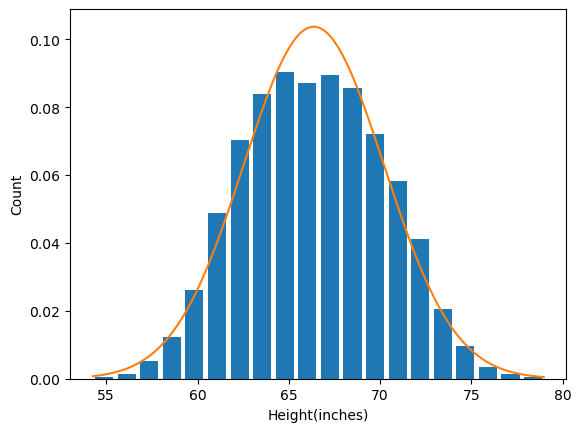

,gender,height
0,Male,73.847017
1,Male,68.781904
2,Male,74.110105
3,Male,71.730978
4,Male,69.881796
...,...,...
9995,Female,66.172652
9996,Female,67.067155
9997,Female,63.867992
9998,Female,69.034243


In [147]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import numpy as np

df= pd.read_csv("C://Users//USER//Downloads//heights.csv")
plt.hist(df['height'], bins=20, rwidth=0.8, density=True)
plt.xlabel('Height(inches)')
plt.ylabel('Count')
rng= np.arange(df['height'].min(), df['height'].max(), 0.1)
plt.plot(rng, norm.pdf(rng, df['height'].mean(), df['height'].std()))
plt.show()
upper_limit= df['height'].mean()+3*df['height'].std()
lower_limit= df['height'].mean()-3*df['height'].std()
df= df[(df['height']<upper_limit) & (df['height']>lower_limit)]
df

## Outlier Removal(Z-Score)

In [148]:
import pandas as pd

df= pd.read_csv("C://Users//USER//Downloads//heights.csv")
df['z_score']= (df['height']-df['height'].mean())/(df['height'].std())
df= df[(df['z_score']<3) & (df['z_score']>-3)]
df

,gender,height,z_score
0,Male,73.847017,1.943964
1,Male,68.781904,0.627505
2,Male,74.110105,2.012343
3,Male,71.730978,1.393991
4,Male,69.881796,0.913375
...,...,...,...
9995,Female,66.172652,-0.050658
9996,Female,67.067155,0.181830
9997,Female,63.867992,-0.649655
9998,Female,69.034243,0.693090


## Outlier Removal(IQR)

In [158]:
import pandas as pd

df= pd.read_csv("C://Users//USER//Downloads//heights.csv")
Q1= df['height'].quantile(0.25)
Q3= df['height'].quantile(0.75)
IQR= Q3-Q1
upper_limit= Q3+1.5*IQR
lower_limit= Q1-1.5*IQR
df= df[(df['height']<upper_limit) & (df['height']>lower_limit)]

## Feature Engineering means all preparatory work you have to do before training a suitable model. This includes: data-cleaning, outlier removal, encoding, principal component analysis and even more.

## Adaptive Boost

In [10]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

iris= load_iris()
df= pd.DataFrame(iris.data, columns= iris.feature_names)
df['target']= iris.target
X= df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]
y= df['target']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2)
for n in [50,60,70,80]:
    model= DecisionTreeClassifier(criterion='entropy', max_depth=1)
    AdaBoost= AdaBoostClassifier(estimator= model, n_estimators=n, learning_rate=0.1)
    AdaBoost.fit(X_train, y_train)
    print(n, AdaBoost.score(X_test, y_test))

50 0.9
60 0.9
70 0.9
80 0.9


## Gradient Boost

In [13]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

iris= load_iris()
df= pd.DataFrame(iris.data, columns= iris.feature_names)
df['target']= iris.target
X= df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]
y= df['target']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2)
for n in [50,60,70,80]:
    model= DecisionTreeClassifier(criterion='entropy', max_depth=1)
    GBoost= GradientBoostingClassifier(n_estimators=n, learning_rate=0.1, max_depth=1)
    GBoost.fit(X_train, y_train)
    print(n, GBoost.score(X_test, y_test))

50 0.9666666666666667
60 0.9333333333333333
70 0.9333333333333333
80 0.9333333333333333


## Extreme Gradient Boost (XGBoost)

In [ ]:
!pip install xgboost

In [25]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

iris= load_iris()
df= pd.DataFrame(iris.data, columns= iris.feature_names)
df['target']= iris.target
X= df[['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']]
y= df['target']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2)
for n in [50,60,70,80]:
    GBoost= XGBClassifier(n_estimators=n, learning_rate=0.1, max_depth=1, eval_metric='mlogloss')
    GBoost.fit(X_train, y_train)
    print(n, GBoost.score(X_test, y_test))

50 0.9333333333333333
60 0.9333333333333333
70 0.9333333333333333
80 0.9333333333333333
